In [19]:
import sys, os
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import matplotlib.pyplot as plt
from pygimli.physics import ERTManager
from pygimli.physics import ert
from sys import path

fs = 8
cMine = 100 
cMaxe = 10000
cMape = 'Spectral_r' #'plasma_r' # Color scale

# 1 Create Synthetic Model
1.1 Geometry

In [20]:
# Model geometry & characteristics 
worldx = [150, 0] #[xmax, xmin]
worldz = [0, -40] #[zmax, zmin]
eoffset = 20 # electrode offset [m] from model boundary

# Layers: geometry & resistivity
interfaces = [-5] #depth of interface(s)
rm = ([5, -3], [5, -28]) #positions (x, z) of region markers for all layers
layerres = np.array([600, 2500]) # resistivity for each layer

## Polygons: geometry & resistivity (comment if not needed)
poly1 = [[90, -15], [50, -15], [50, -5], [90, -5]] #[[x1,z1], [x2,z2], ..., [xn,zn]]
rmpoly = ([70, -10]) #positions (x, z) of region markers for all polygons
polyres = np.array([50]) # resistivity for each polygon

1.2 Mesh

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x7fb2606a2e30>)

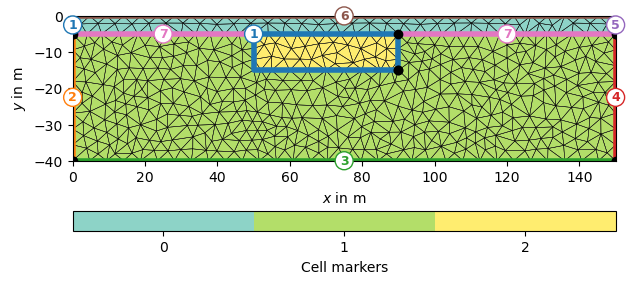

In [21]:
# MESH CREATION 
world = mt.createWorld(worldz, worldx, layers=interfaces, worldMarker=False)
geom = world

# ADD POLYGONS
if 'rmpoly' in locals():
    rm += (rmpoly,)
    layerres = np.append(layerres,polyres)
    block1 =  mt.createPolygon(poly1, isClosed=True)
    geom = mt.mergePLC([world, block1])
    # block2 =  mt.createPolygon(poly2, isClosed=True)
    # geom = mt.mergePLC([world, block1, block2])

# ADD REGION MARKERS AND DEFINE LAYER RESISTIVITY
for i in range(len(rm)):
    geom.addRegionMarker(rm[i], i)  

# CREATE UNSTRUCTURED MESH 
area = 10 # Mesh Geometry
mesh = mt.createMesh(geom, area=area)
pg.show(mesh, markers=True, showMesh=True)

1.3 Attribute Resistivities to Layers

Number of layers:  3
Layer resistivity (Ωm):  [ 600. 2500.   50.]


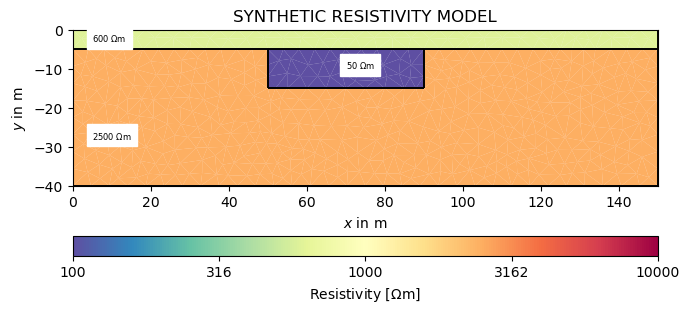

In [22]:
# Model creation based on prescribed layer resistivities
def to_mesh(data):
    return data[mesh.cellMarkers()]
rhotrue = to_mesh(layerres)

print("Number of layers: ", len(layerres))
print("Layer resistivity (\u03A9m): ", np.rint(layerres))

# Plot SYN RES
fig, ax = pg.plt.subplots(1,1,figsize=(7,4))
pg.show(ax=ax, mesh=mesh, data=rhotrue, logScale=True, label='Resistivity [$\Omega$m]', cMin=cMine, cMax=cMaxe, grid=True, cMap=cMape, hold=True)
ax.set_title("SYNTHETIC RESISTIVITY MODEL")

tr = ["","","","",""]
for i,j in enumerate(layerres):
    tr[i] = "%.0f $\Omega$m" % np.rint(layerres[i])
    ax.text(rm[i][0],rm[i][1], tr[i], size=6, backgroundcolor='white')

# 2 Simulate apparent resistivities (Forward Modelling)
--> Result: Pseudosection (= calculated measured (apparent) resistivities for a hypothetic survey with hypothetic electrode spacing and configuration)

Number of sensors:  55
Sensor spacing:  2.0  m


14/04/25 - 08:07:35 - pyGIMLi - INFO - Found 2 regions.
14/04/25 - 08:07:35 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
14/04/25 - 08:07:35 - Core - INFO - Create H2 refined mesh for forward tasks.
14/04/25 - 08:07:36 - pyGIMLi - INFO - Found 2 regions.
14/04/25 - 08:07:36 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x7fb2603f2950>)

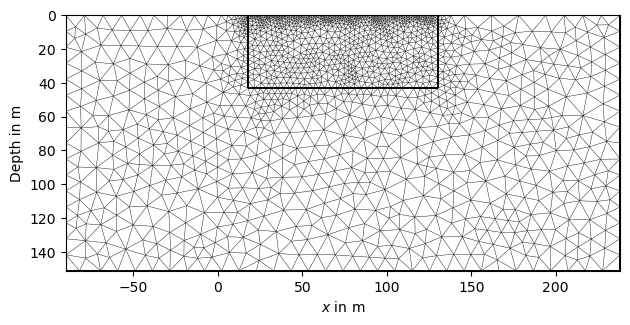

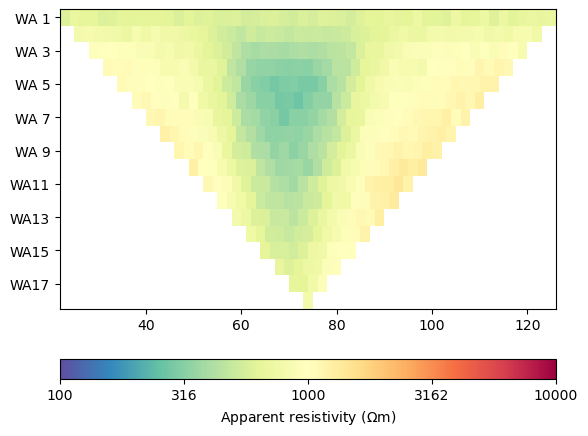

In [23]:
### Some settings ###################
paraDX = 0.5
paraMaxCellSize = 10
noiselevel = 0.05 # add relative noise to the simulated data. noiseLevel*100 in % (0.025 = 2.5 %)
xbound = 100
ybound = 100

#ERT
lamERT = 5
zWeightERT = 0.2
maxIterERT = 6

spacing = 2 #sensor spacing [m] 
senposmin, senposmax = np.min(worldx)+eoffset, np.max(worldx)-eoffset #position first/last sensor (within worldx)
sensors = np.arange(senposmin, senposmax, spacing, dtype="float")
print("Number of sensors: ", len(sensors))
print("Sensor spacing: ", sensors[1]-sensors[0], " m")

# ERT Config
ERT_config = 'wa' #other schemes ['wa', 'dd', 'slm']
if ERT_config == 'dd': 
    dd_spacings=[1,3,5,7,9,12] #only for dd
    ertScheme = ert.createData(sensors, ERT_config, spacings=dd_spacings)
else: 
    ertScheme = ert.createData(sensors, ERT_config)
k = ert.geometricFactors(ertScheme)
ertScheme.markInvalid(pg.abs(k) > 5000)
ertScheme.removeInvalid()
ertm = ERTManager()

# Create suitable mesh for ert forward calculation
meshERTFWD = mt.createParaMesh(ertScheme, paraDX=paraDX, paraMaxCellSize=paraMaxCellSize,
                               boundaryMaxCellSize=70, paraBoundary=1,boundary=1, quality=33.8)
pg.show(meshERTFWD)
#meshtest=meshERTFWD

res = pg.Vector()
pg.interpolate(mesh, rhotrue, meshERTFWD.cellCenters(), res)
res = mt.fillEmptyToCellArray(meshERTFWD, res, slope=True)
ertm.setMesh(meshERTFWD)
ertm.fop.createRefinedForwardMesh()
ertData = ertm.simulate(mesh=meshERTFWD, scheme=ertScheme, res=res, noiseLevel=noiselevel, noiseAbs=0.0, verbose=False)

ertm.setData(ertData)
ertm.setMesh(meshERTFWD)
ertm.inv.dataVals = ertData("rhoa")
pg.show(ertData, cMap=cMape, cMin=cMine, cMax=cMaxe)

# 3 Inversion (Inverse modelling)
3.1 Mesh generation

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

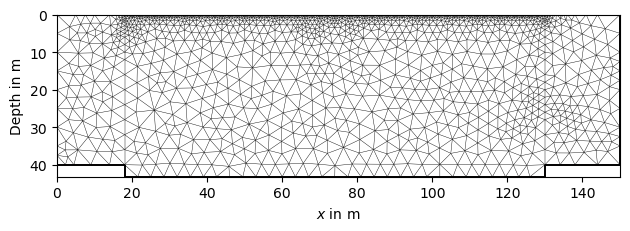

In [24]:
### MESH ######################################################################
world = geom #needed for plots
plc = mt.createParaMeshPLC(ertData, paraDepth=np.min(worldz), paraDX=paraDX,     
                           paraBoundary=1, boundary=0, paraMaxCellSize=paraMaxCellSize)

for sensor in ertData.sensorPositions():
    plc.createNode([sensor.x(), sensor.y() - 0.1])
rect = mt.createRectangle([mesh.xmin(), mesh.ymin()], [mesh.xmax(), mesh.ymax()], boundaryMarker=0)
geom = mt.mergePLC([plc, rect])
meshERT0 = mt.createMesh(geom, quality=34, area=area, smooth=True) 
for cell in meshERT0.cells():
    cell.setMarker(2)
for boundary in meshERT0.boundaries():
    boundary.setMarker(0)
meshERT = mt.appendTriangleBoundary(meshERT0, xbound=xbound, ybound=ybound, quality=34, isSubSurface=True)

pg.show(meshERT)

3.2 Inversion (this cell may take some time to run)

--> Result: Tomogram with true (specific) resistivites (should ideally be similar to the synthetic model)

14/04/25 - 08:07:44 - pyGIMLi - INFO - Found 1 regions.
14/04/25 - 08:07:44 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/04/25 - 08:07:44 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/04/25 - 08:07:44 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 7903 Cells: 14752 Boundaries: 11590
14/04/25 - 08:07:45 - pyGIMLi - INFO - Use median(data values)=702.0368154572813


Text(0.5, 1.0, 'Synthetic model for comparison')

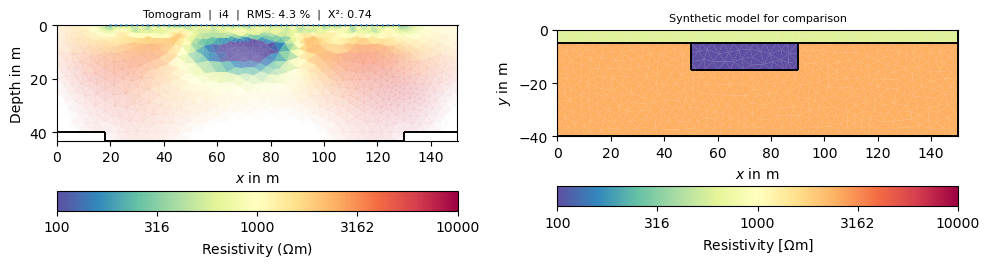

In [25]:
ertm.setMesh(meshERT)
resinv = ertm.invert(ertData, lam=lamERT, zWeight=zWeightERT, maxIter=maxIterERT, showProgress=False, verbose=False) #showProgress=True
rmschi1=f'i{len(ertm.inv.chi2History)}  |  RMS: {ertm.inv.relrms():.1f} %  |  \u03A7\N{superscript two}: {ertm.inv.chi2():.2f}'

fig, axes = pg.plt.subplots(1,2,figsize=(10,6))
ax=axes[0]
ertm.showResult(resinv,ax,logScale=True, cMin=cMine, cMax=cMaxe, cMap=cMape, hold=True)
#pg.show(mesh=mesh, ax=ax, fillRegion=False, regionMarker=False) #, markers=False, showMesh=False) #test mesh=mesh
ax.set_title("Tomogram  |  "+rmschi1, fontsize = fs)
ax=axes[1]
pg.show(ax=ax, mesh=mesh, data=rhotrue, logScale=True, label='Resistivity [$\Omega$m]', cMin=cMine, cMax=cMaxe, grid=True, cMap=cMape, hold=True)
ax.set_title("Synthetic model for comparison", fontsize = fs)

array([<Axes: >, <Axes: >], dtype=object)

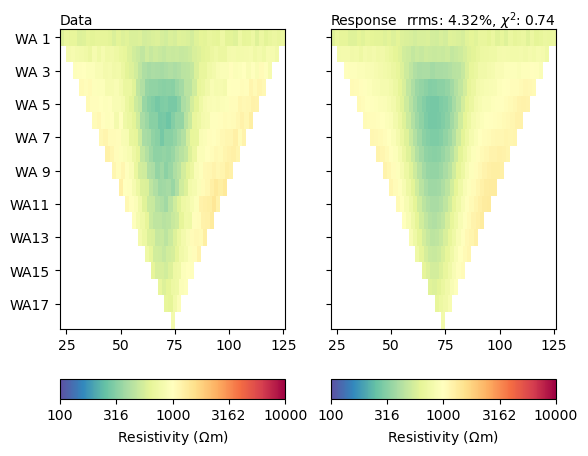

In [26]:
#ertm.showResultAndFit(cMin=cMine, cMax=cMaxe, cMap=cMape, title=case+"  |  "+rmschi1)
ertm.showFit(cMin=cMine, cMax=cMaxe, cMap=cMape)

### ______________________________________
# 4 NOW IT'S YOUR TURN:
 
## 4.1 Adjust the synthetic model step by step and discover how the tomogram changes (follow the instructions in the exercise)

a) Depth of the interface (try -15 m)   
b) Layer resistivities (try different resistivity contrasts),    
c) Electrode spacing (try 5m spacing),    
d) Electrode configuration (try Dipole-Dipole instead of Wenner)   

In [27]:
# a) Change the depth of the interface and polygon:
interfaces = [-15]  # depth of interface(s)
polyz1 = -5        # upper boundary of polygon [-m]
polyz2 = -15       # lower boundary of polygon [-m]

# b) Change the values of the layer resistivities:
layerres = np.array([600, 2500])  # resistivity for each layer
polyres = np.array([50]) # resistivity for each polygon

# c) Change the sensor spacing:
spacing = 2  #sensor spacing [m] 

# d) Change the Electrode Configuration:
ERT_config = 'wa'  #possible configurations: 'wa' (Wenner) , 'dd' (dipole dipole), 'slm' (Wenner Schlumberger)

#### Don't touch this ##############
rm = ([5, interfaces[0]+2], [5, -28]) #positions (x, z) of region markers for all layers
poly1 = [[90, polyz2], [50, polyz2], [50, polyz1], [90, polyz1]] #[[x1,z1], [x2,z2], ..., [xn,zn]]
rmpoly = ([70, polyz2+2]) #positions (x, z) of region markers for all polygons
eoffset = 20

### 4.2 Update mesh, Simulate data, and Invert the new model

14/04/25 - 08:13:11 - pyGIMLi - INFO - Found 2 regions.
14/04/25 - 08:13:11 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
14/04/25 - 08:13:11 - Core - INFO - Create H2 refined mesh for forward tasks.


Number of sensors:  55
Sensor spacing:  2.0  m
Profile length:  108.0  m


14/04/25 - 08:13:12 - pyGIMLi - INFO - Found 2 regions.
14/04/25 - 08:13:12 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
14/04/25 - 08:13:12 - pyGIMLi - INFO - Found 1 regions.
14/04/25 - 08:13:12 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/04/25 - 08:13:12 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/04/25 - 08:13:13 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 7903 Cells: 14752 Boundaries: 11590
14/04/25 - 08:13:13 - pyGIMLi - INFO - Use median(data values)=531.015401518782


Text(0.5, 1.0, 'INVERTED SYNTHETIC DATA  |  electrode spacing: 2m | config: wa')

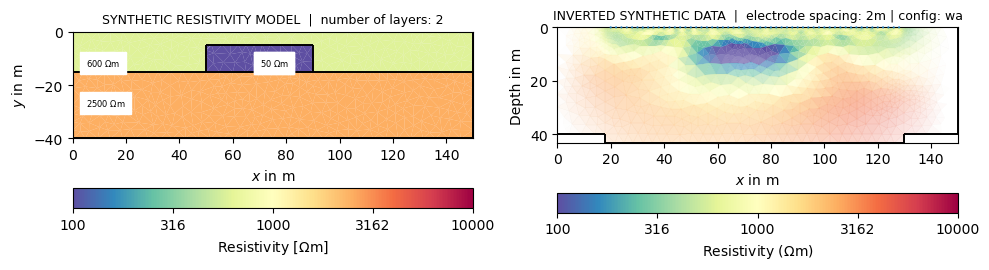

In [29]:
### Update Mesh ###################################
#rm = ([5, -2], [5, -7], [5, -28]) #positions (x, z) of region markers for all layers

world = mt.createWorld(worldz, worldx, layers=interfaces, worldMarker=False)
geom = world

# ADD POLYGONS
if 'rmpoly' in locals():
    rm += (rmpoly,)
    layerres = np.append(layerres,polyres)
    block1 =  mt.createPolygon(poly1, isClosed=True)
    geom = mt.mergePLC([world, block1])
    # block2 =  mt.createPolygon(poly2, isClosed=True)
    # geom = mt.mergePLC([world, block1, block2])

senposmin, senposmax = np.min(worldx)+eoffset, np.max(worldx)-eoffset #position first/last sensor (within worldx)
sensors = np.arange(senposmin, senposmax, spacing, dtype="float")
print("Sensor spacing: ", sensors[1]-sensors[0], " m")
print("Number of sensors: ", len(sensors))
print("Profile length: ", (len(sensors)-1)*(sensors[1]-sensors[0]), " m")

for i in range(len(rm)):
    geom.addRegionMarker(rm[i], i)  
mesh = mt.createMesh(geom, area=area)
#pg.show(mesh, markers=True, showMesh=True)
rhotrue = to_mesh(layerres)

### SIMULATE DATA ###############
if ERT_config == 'dd': 
    dd_spacings=[1,3,5,7,9] #only for dd
    ertScheme = ert.createData(sensors, ERT_config, spacings=dd_spacings)
else: 
    ertScheme = ert.createData(sensors, ERT_config)
k = ert.geometricFactors(ertScheme)
ertScheme.markInvalid(pg.abs(k) > 5000)
ertScheme.removeInvalid()

# Create suitable mesh for ert forward calculation
meshERTFWD = mt.createParaMesh(ertScheme, paraDX=paraDX, paraMaxCellSize=paraMaxCellSize,
                               boundaryMaxCellSize=70, paraBoundary=1,boundary=1, quality=34)

res = pg.Vector()
pg.interpolate(mesh, rhotrue, meshERTFWD.cellCenters(), res)
res = mt.fillEmptyToCellArray(meshERTFWD, res, slope=True)
ertm.setMesh(meshERTFWD)
ertm.fop.createRefinedForwardMesh()
ertData = ertm.simulate(mesh=meshERTFWD, scheme=ertScheme, res=res, noiseLevel=noiselevel, noiseAbs=0.0, verbose=False)
ertm.setData(ertData)
ertm.setMesh(meshERTFWD)
ertm.inv.dataVals = ertData("rhoa")
#pg.show(ertData, cMap=cMape, cMin=cMine, cMax=cMaxe)


### MESH ######################################################################
plc = mt.createParaMeshPLC(ertData, paraDepth=np.min(worldz), paraDX=paraDX, paraBoundary=1, 
                           boundary=0, boundaryMaxCellSize=70, paraMaxCellSize=paraMaxCellSize)
for sensor in ertData.sensorPositions():
    plc.createNode([sensor.x(), sensor.y() - 0.1])
rect = mt.createRectangle([mesh.xmin(), mesh.ymin()], [mesh.xmax(), mesh.ymax()], boundaryMarker=0)
geom = mt.mergePLC([plc, rect])
meshERT0 = mt.createMesh(geom, quality=34, area=area, smooth=True) 

for cell in meshERT0.cells():
    cell.setMarker(2)
for boundary in meshERT0.boundaries():
    boundary.setMarker(0)
meshERT = mt.appendTriangleBoundary(meshERT0, xbound=xbound, ybound=ybound, quality=34, isSubSurface=True)
#pg.show(meshERT)

### INVERSION ##############################################################
ertm.setMesh(meshERT)
resinv = ertm.invert(ertData, lam=lamERT, zWeight=zWeightERT, maxIter=maxIterERT, verbose=False) #showProgress=True
rmschi1=f'i{len(ertm.inv.chi2History)}  |  RMS: {ertm.inv.relrms():.1f} %  |  \u03A7\N{superscript two}: {ertm.inv.chi2():.2f}  |  $\lambda$: {lamERT:.0f}  |  zW: {zWeightERT:.2f}'

### PLOT ##############################################
fig, axes = pg.plt.subplots(1,2,figsize=(10,5))
ax=axes[0]
pg.show(ax=ax, mesh=mesh, data=rhotrue, logScale=True, label='Resistivity [$\Omega$m]', cMin=cMine, cMax=cMaxe, grid=True, cMap=cMape, hold=True)
ax.set_title("SYNTHETIC RESISTIVITY MODEL  |  number of layers: "+str(len(interfaces)+1), fontsize = 9)
tr = ["","","","",""]
for i,j in enumerate(layerres):
    tr[i] = "%.0f $\Omega$m" % np.rint(layerres[i])
    ax.text(rm[i][0],rm[i][1], tr[i], size=6, backgroundcolor='white')
    
ax=axes[1]
ertm.showResult(resinv,ax,logScale=True, cMin=cMine, cMax=cMaxe, cMap=cMape, hold=True)
#pg.show(mesh=mesh, ax=ax, fillRegion=False, regionMarker=False) #, markers=False, showMesh=False) #test mesh=mesh
ax.set_title("INVERTED SYNTHETIC DATA  |  electrode spacing: "+str(spacing)+"m | config: "+str(ERT_config), fontsize = 9)